[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter10_seminar_notebook.ipynb)

# Modelling Financial Markets — Seminar 10: Market Microstructure

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza, Bucharest University of Economic Studies.*

- **[Solved]** problems contain the full solution; **[Proposed]** problems are solved by you.
- Part A: pen and paper (A1–A9); Part B: estimation and inference (B1–B7); Part C: open question.

> The solutions are discussed in the seminar.

In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [ ]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Gray     = '#7F7F7F'   # doar linii de referinta
GROUP_COL = {'US': MainBlue, 'BVB': IDAred, 'Crypto': Amber}

HERE = '.'
SEED = 42
START2 = '2024-09-19'
START10 = '2016-09-19'
B_BOOT = 1000



def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, handles, labels, ncol=3, y=0.0):
    """O singura legenda pentru o figura cu mai multe panouri, sub figura."""
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple, np.ndarray)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    if isinstance(o, (np.bool_,)):
        return bool(o)
    return o

## Data

- SPY 5-minute bars, regular session (09:30–16:00 New York time), October 2020 – September 2026; Bitcoin 5-minute bars (UTC), September 2024 – September 2026.
- Daily open, high, low, close and volume for US stocks, Bucharest Stock Exchange (BVB) stocks and crypto-assets; prices adjusted for dividends and splits.
- BVB traded values converted from lei to USD at the BNR reference rate; crypto traded values are in USD.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# cheie -> (simbol, eticheta, grup)
ASSETS = {
    'SPY': ('SPY.US', 'SPY', 'US'), 'AAPL': ('AAPL.US', 'Apple', 'US'), 'MSFT': ('MSFT.US', 'Microsoft', 'US'),
    'NVDA': ('NVDA.US', 'NVIDIA', 'US'), 'JPM': ('JPM.US', 'JPMorgan', 'US'), 'GME': ('GME.US', 'GameStop', 'US'),
    'MSTR': ('MSTR.US', 'Strategy', 'US'),
    'TLV': ('TLV.RO', 'Banca Transilvania', 'BVB'), 'SNP': ('SNP.RO', 'OMV Petrom', 'BVB'),
    'H2O': ('H2O.RO', 'Hidroelectrica', 'BVB'), 'BRD': ('BRD.RO', 'BRD', 'BVB'), 'SNG': ('SNG.RO', 'Romgaz', 'BVB'),
    'SNN': ('SNN.RO', 'Nuclearelectrica', 'BVB'), 'TGN': ('TGN.RO', 'Transgaz', 'BVB'),
    'EL': ('EL.RO', 'Electrica', 'BVB'), 'DIGI': ('DIGI.RO', 'Digi', 'BVB'), 'TEL': ('TEL.RO', 'Transelectrica', 'BVB'),
    'TVBETETF': ('TVBETETF.RO', 'BET ETF', 'BVB'),
    'BTC': ('BTC-USD.CC', 'Bitcoin', 'Crypto'), 'ETH': ('ETH-USD.CC', 'Ethereum', 'Crypto'),
    'SOL': ('SOL-USD.CC', 'Solana', 'Crypto'), 'XRP': ('XRP-USD.CC', 'XRP', 'Crypto'),
    'DOGE': ('DOGE-USD.CC', 'Dogecoin', 'Crypto'), 'ADA': ('ADA-USD.CC', 'Cardano', 'Crypto'),
    'LTC': ('LTC-USD.CC', 'Litecoin', 'Crypto'),
}
GROUPS = {g: [k for k, v in ASSETS.items() if v[2] == g] for g in ('US', 'BVB', 'Crypto')}
LABELS = {k: v[1] for k, v in ASSETS.items()}

_CACHE = {}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    if symbol in _CACHE:
        return _CACHE[symbol]
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    _CACHE[symbol] = pd.read_csv(src, index_col='date', parse_dates=True).sort_index()
    return _CACHE[symbol]


def read_reference_rate(currency='USD', start='2014-01-01', end=END):
    """Cursul oficial de referinta RON (arhive XML anuale BNR)."""
    key = ('REF', currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'rate']).drop_duplicates('date').set_index('date')['rate']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def _clean(key, d):
    d = d[(d['high'] > d['low']) & (d['volume'].fillna(0) > 0)]
    if ASSETS[key][2] != 'Crypto':
        d = d[d.index.dayofweek < 5]
        # cotatii eronate izolate: pretul ajustat de peste doua ori mai mare / mai mic decat mediana locala (21 de zile)
        med = d['adjusted_close'].rolling(21, center=True, min_periods=5).median()
        d = d[np.abs(np.log(d['adjusted_close'] / med)) < np.log(2)]
    return d


def ohlc(key, start='2016-09-19', end=END):
    """Deschidere, maxim, minim, inchidere ajustate cu factorul pretului ajustat (dividende si split-uri)."""
    d = read_market(ASSETS[key][0]).loc[start:end].copy()
    f = d['adjusted_close'] / d['close']
    for c in ['open', 'high', 'low', 'close']:
        d[c] = d[c] * f
    return _clean(key, d)[['open', 'high', 'low', 'close', 'volume']]


def split_adjusted_close(d):
    """Pretul de inchidere ajustat DOAR pentru split-uri (aceeasi baza ca volumul in numar de actiuni)."""
    k = (d['close'].shift(1) / d['close']) / (d['adjusted_close'].shift(1) / d['adjusted_close'])
    k = k.where(np.abs(np.log(k)) > 0.15, 1.0).fillna(1.0)      # zilele de split: raportul de divizare
    back = k[::-1].cumprod()[::-1].shift(-1).fillna(1.0)          # produsul split-urilor ulterioare fiecarei zile
    return d['close'] / back


def returns(key, start='2016-09-19', end=END):
    """Randamente log zilnice din pretul ajustat (zilele fara tranzactii eliminate)."""
    d = read_market(ASSETS[key][0]).loc[start:end]
    d = _clean(key, d)
    return np.log(d['adjusted_close']).diff().dropna().rename(key)


def dollar_volume(key, start='2016-09-19', end=END):
    """Valoarea tranzactionata zilnic, in USD."""
    d = read_market(ASSETS[key][0]).loc[:end]
    grp = ASSETS[key][2]
    if grp == 'Crypto':
        dv = d['volume']                                          # deja in USD
    else:
        dv = split_adjusted_close(d) * d['volume']
        if grp == 'BVB':                                          # RON -> USD la cursul de referinta BNR
            fx = read_reference_rate('USD', start='2014-01-01', end=end)
            dv = dv / fx.reindex(dv.index).ffill()
    d = _clean(key, d.assign(dv=dv))
    return d['dv'].loc[start:end].dropna().rename(key)


def intraday_spy():
    """Bare de 5 minute SPY, sesiunea regulata (09:30-15:55 = inceputul barei), doar zilele complete (78 de bare)."""
    fname = 'intraday/SPY.US_5m.csv'
    path = os.path.join(MARKET_DIR, fname)
    d = pd.read_csv(path if os.path.exists(path) else REPO_RAW + fname, parse_dates=['datetime_utc'])
    t = d['datetime_utc'].dt.tz_localize('UTC').dt.tz_convert('America/New_York').dt.tz_localize(None)
    d = d.assign(t=t, date=t.dt.normalize(), tod=t.dt.strftime('%H:%M')).drop(columns='datetime_utc')
    d = d[(d['tod'] >= '09:30') & (d['tod'] <= '15:55')]
    n = d.groupby('date').size()
    d = d[d['date'].isin(n[n == 78].index)].set_index('t').sort_index()
    d['r'] = np.log(d['close']).groupby(d['date']).diff()
    first = d['tod'] == '09:30'
    d.loc[first, 'r'] = np.log(d.loc[first, 'close'] / d.loc[first, 'open'])   # prima bara: de la deschidere
    d['dv'] = d['close'] * d['volume']
    return d


def intraday_btc():
    """Bare de 5 minute Bitcoin (UTC), 24 de ore din 24; volumul nu este folosit (lipseste pe multe bare)."""
    fname = 'intraday/BTC-USD.CC_5m.csv'
    path = os.path.join(MARKET_DIR, fname)
    d = pd.read_csv(path if os.path.exists(path) else REPO_RAW + fname, parse_dates=['datetime_utc'])
    d = d.set_index('datetime_utc').sort_index()
    d = d[~d.index.duplicated()]
    d['date'] = d.index.normalize()
    d['r'] = np.log(d['close']).diff()
    gap = d.index.to_series().diff() != pd.Timedelta('5min')
    d.loc[gap, 'r'] = np.nan                                       # fara randamente peste goluri
    return d

## Estimators and models

- `roll_spread`, `cs_spread`, `ar_terms`, `amihud`: spread and illiquidity measures.
- `walk_book`, `zi_simulate`: order book execution and a simulated order book.
- `gm_quotes`, `gm_simulate`, `kyle`, `ac_trajectory`, `ac_frontier`: Glosten–Milgrom, Kyle and Almgren–Chriss.

In [ ]:
def roll_spread(close):
    """Spread-ul relativ Roll din covarianta de ordinul 1 a randamentelor log; NaN daca covarianta este pozitiva."""
    r = np.log(np.asarray(close, float))
    dp = np.diff(r)
    c = np.mean((dp[1:] - dp.mean()) * (dp[:-1] - dp.mean()))
    return (2 * np.sqrt(-c) if c < 0 else np.nan), c


def cs_spread(high, low):
    """Estimatorul Corwin-Schultz pentru fiecare pereche de perioade consecutive (valorile negative devin 0)."""
    h, l = np.log(np.asarray(high, float)), np.log(np.asarray(low, float))
    beta = (h[:-1] - l[:-1]) ** 2 + (h[1:] - l[1:]) ** 2
    gamma = (np.maximum(h[:-1], h[1:]) - np.minimum(l[:-1], l[1:])) ** 2
    k = 3 - 2 * np.sqrt(2)
    alpha = (np.sqrt(2 * beta) - np.sqrt(beta)) / k - np.sqrt(gamma / k)
    return np.clip(2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha)), 0, None)


def ar_terms(close, high, low):
    """Termenii Abdi-Ranaldo: 4 (c_t - eta_t)(c_t - eta_{t+1}); media lor estimeaza s^2."""
    c = np.log(np.asarray(close, float))
    eta = (np.log(np.asarray(high, float)) + np.log(np.asarray(low, float))) / 2
    return 4 * (c[:-1] - eta[:-1]) * (c[:-1] - eta[1:])


def ar_spread(close, high, low):
    """Spread-ul relativ Abdi-Ranaldo: sqrt(max(media termenilor, 0))."""
    m = np.mean(ar_terms(close, high, low))
    return np.sqrt(max(m, 0.0)), m


def amihud(r, dv, scale=1e6):
    """Iliciditatea Amihud: media |r| (puncte de baza) la 1 milion USD tranzactionat."""
    x = pd.concat([r.rename('r'), dv.rename('dv')], axis=1, join='inner').dropna()
    x = x[x['dv'] > 0]
    return float((1e4 * x['r'].abs() / (x['dv'] / scale)).mean())


def daily_estimates(d):
    """Estimatorii de spread pe o fereastra de bare (o zi de bare intraday sau o perioada de date zilnice)."""
    rs, cov = roll_spread(d['close'])
    cs = cs_spread(d['high'], d['low'])
    ar2 = ar_terms(d['close'], d['high'], d['low'])
    return pd.Series(dict(cov=cov, roll=rs, cs=cs.mean(), ar2=ar2.mean()))


def walk_book(asks, qty):
    """Ordin de cumparare la piata de marime qty pe ofertele de vanzare asks = [(pret, cantitate), ...] crescator.
    Intoarce executiile, pretul mediu ponderat si ofertele ramase."""
    fills, left, rest = [], qty, []
    for p, q in asks:
        if left <= 0:
            rest.append((p, q))
            continue
        take = min(q, left)
        fills.append((p, take))
        left -= take
        if q > take:
            rest.append((p, q - take))
    vwap = sum(p * q for p, q in fills) / sum(q for _, q in fills)
    return fills, vwap, rest, left


def gm_quotes(theta, mu, vl, vh):
    """Cotatiile ask si bid: asteptarea valorii conditionat de o cumparare, respectiv de o vanzare.
    theta = P(V = vh), mu = ponderea investitorilor informati; cei neinformati cumpara sau vand cu prob. 1/2."""
    pb_h, pb_l = mu + (1 - mu) / 2, (1 - mu) / 2               # P(cumparare | V = vh), P(cumparare | V = vl)
    th_b = pb_h * theta / (pb_h * theta + pb_l * (1 - theta))   # P(V = vh | cumparare)
    th_s = pb_l * theta / (pb_l * theta + pb_h * (1 - theta))   # P(V = vh | vanzare)
    return vl + th_b * (vh - vl), vl + th_s * (vh - vl), th_b, th_s


def gm_simulate(mu, vl=90.0, vh=110.0, v=110.0, n=60, seed=1):
    """Un sir de tranzactii cand valoarea adevarata este v; formatorul de piata invata din fluxul de ordine."""
    rng = np.random.default_rng(seed)
    theta, rows = 0.5, []
    for t in range(n):
        ask, bid, th_b, th_s = gm_quotes(theta, mu, vl, vh)
        informed = rng.random() < mu
        buy = (v == vh) if informed else (rng.random() < 0.5)
        rows.append(dict(t=t, ask=ask, bid=bid, theta=theta, buy=buy))
        theta = th_b if buy else th_s
    return pd.DataFrame(rows)


def kyle(sigma_v, sigma_u):
    """Echilibrul Kyle: v ~ N(p0, sigma_v^2), cererea zgomotoasa u ~ N(0, sigma_u^2).
    Strategia informatului x = beta (v - p0), pretul p = p0 + lambda (x + u)."""
    beta = sigma_u / sigma_v
    lam = sigma_v / (2 * sigma_u)
    profit = sigma_v * sigma_u / 2
    return dict(beta=beta, lam=lam, profit=profit, post_var=sigma_v ** 2 / 2)


def ac_trajectory(X, T, N, sigma, eta, gamma, lam, eps=0.0):
    """Traiectoria optima de lichidare (formulele exacte in timp discret).
    X actiuni de vandut in T zile, N intervale; sigma = volatilitatea pretului (USD / zi^0.5);
    impact temporar h(v) = eps sgn + eta v; impact permanent g(v) = gamma v; lam = aversiunea la risc."""
    tau = T / N
    eta_t = eta - gamma * tau / 2
    t = np.arange(N + 1) * tau
    if lam == 0:
        x = X * (1 - t / T)
    else:
        kt2 = lam * sigma ** 2 / eta_t                       # kappa_tilde^2
        kappa = np.arccosh(kt2 * tau ** 2 / 2 + 1) / tau
        x = X * np.sinh(kappa * (T - t)) / np.sinh(kappa * T)
    n = -np.diff(x)
    E = 0.5 * gamma * X ** 2 + eps * X + eta_t / tau * np.sum(n ** 2)
    V = sigma ** 2 * tau * np.sum(x[1:] ** 2)
    return t, x, E, V


def ac_frontier(X, T, N, sigma, eta, gamma, lams):
    """Frontiera eficienta (abaterea standard, costul asteptat) pentru mai multe aversiuni la risc."""
    out = []
    for lam in lams:
        _, _, E, V = ac_trajectory(X, T, N, sigma, eta, gamma, lam)
        out.append((lam, E, np.sqrt(V)))
    return pd.DataFrame(out, columns=['lam', 'E', 'sd'])


def zi_simulate(n_events=300_000, L=40, rate_limit=1.0, rate_market=0.25, rate_cancel=0.025, n_ticks=4000, seed=7):
    """Ordine limita (uniform pe L tick-uri de la cotatia opusa), ordine la piata si anulari, toate de o unitate.
    Intoarce seria (mijloc, spread) si instantanee ale registrului."""
    rng = np.random.default_rng(seed)
    bid_q = np.zeros(n_ticks, int)
    ask_q = np.zeros(n_ticks, int)
    mid0 = n_ticks // 2
    bid_q[mid0 - 20:mid0] = 3
    ask_q[mid0 + 1:mid0 + 21] = 3
    rows, snaps, offset = [], [], 0
    for e in range(n_events):
        bb = np.flatnonzero(bid_q)[-1]
        ba = np.flatnonzero(ask_q)[0]
        n_orders = bid_q.sum() + ask_q.sum()
        w = np.array([2 * L * rate_limit, 2 * rate_market, rate_cancel * n_orders])
        u = rng.random() * w.sum()
        side = rng.random() < 0.5
        if u < w[0]:                                   # ordin limita
            k = rng.integers(1, L + 1)
            if side:
                p = ba - k
                bid_q[p] += 1
            else:
                p = bb + k
                ask_q[p] += 1
        elif u < w[0] + w[1]:                          # ordin la piata
            if side:
                ask_q[ba] -= 1 if ask_q[ba] > 0 else 0
            else:
                bid_q[bb] -= 1 if bid_q[bb] > 0 else 0
        else:                                          # anulare a unui ordin existent, ales uniform
            if side and bid_q.sum() > 1:
                idx = rng.choice(np.flatnonzero(bid_q), p=bid_q[bid_q > 0] / bid_q.sum())
                bid_q[idx] -= 1
            elif (not side) and ask_q.sum() > 1:
                idx = rng.choice(np.flatnonzero(ask_q), p=ask_q[ask_q > 0] / ask_q.sum())
                ask_q[idx] -= 1
        if not bid_q.any():
            bid_q[bb] = 1
        if not ask_q.any():
            ask_q[ba] = 1
        bb = np.flatnonzero(bid_q)[-1]
        ba = np.flatnonzero(ask_q)[0]
        if bb < 5 * L or ba > n_ticks - 5 * L:         # recentrare: registrul ramane in mijlocul grilei
            sh = int((bb + ba) / 2 - n_ticks // 2)
            bid_q, ask_q = np.roll(bid_q, -sh), np.roll(ask_q, -sh)
            if sh > 0:
                bid_q[-sh:] = 0
                ask_q[-sh:] = 0
            else:
                bid_q[:-sh] = 0
                ask_q[:-sh] = 0
            offset += sh
        if e % 50 == 0:
            bb = np.flatnonzero(bid_q)[-1]
            ba = np.flatnonzero(ask_q)[0]
            rows.append((e, (bb + ba) / 2 - mid0 + offset, ba - bb))
        if e > n_events // 3 and e % 1000 == 0:
            bb = np.flatnonzero(bid_q)[-1]
            ba = np.flatnonzero(ask_q)[0]
            m = (bb + ba) / 2
            rel = np.arange(n_ticks) - m
            sel = np.abs(rel) <= 30
            snaps.append(pd.DataFrame({'rel': rel[sel], 'bid': bid_q[sel], 'ask': ask_q[sel]}))
    path = pd.DataFrame(rows, columns=['event', 'mid', 'spread'])
    return path, snaps, (bid_q, ask_q)

## Seminar functions

- The order book of Part A, the day-block bootstrap and the tables used in Part B.

In [ ]:
BOOK_ASKS = [(100.02, 300), (100.03, 500), (100.05, 400), (100.08, 1000)]
BOOK_BIDS = [(99.98, 400), (99.97, 600), (99.95, 800), (99.9, 1500)]
B = 1000
AC = {'X': 1000000.0, 'T': 5, 'N': 5, 'sigma': 0.95, 'eta': 2.5e-06, 'gamma': 2.5e-07}
C_MARKETS = {'BVB': {'ret': ('BETTR.INDX', 'close'), 'keys': ['TLV', 'SNP', 'H2O', 'BRD', 'SNG', 'SNN', 'TGN', 'EL', 'DIGI', 'TEL']}, 'US': {'ret': ('SPY.US', 'adjusted_close'), 'keys': ['AAPL', 'MSFT', 'NVDA', 'JPM', 'GME', 'MSTR']}, 'Crypto': {'ret': ('BTC-USD.CC', 'close'), 'keys': ['ETH', 'SOL', 'XRP', 'DOGE', 'ADA', 'LTC']}}


def boot_days(values_by_day, stat, B=B, seed=SEED):
    """Bootstrap pe zile (blocuri = zile intregi): interval percentil de 95% pentru stat(esantion de zile)."""
    rng = np.random.default_rng(seed)
    days = np.array(list(values_by_day.keys()))
    out = []
    for _ in range(B):
        pick = rng.choice(days, len(days), replace=True)
        out.append(stat([values_by_day[d] for d in pick]))
    return float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))


def spy_tod(s):
    """Profilul pe intervale de 5 minute: media |r| (pb), volumul median (milioane de actiuni), ponderea in volumul zilei."""
    x = s.dropna(subset=['r'])
    tod = x.groupby('tod').agg(absr=('r', lambda v: 1e4 * v.abs().mean()), vol=('volume', 'median'))
    share = (s['volume'] / s.groupby('date')['volume'].transform('sum')).groupby(s['tod']).mean()
    tod['share'] = 100 * share
    return tod


def intraday_spreads(s):
    """Estimatorii Roll, Corwin-Schultz si Abdi-Ranaldo calculati pe barele de 5 minute ale fiecarei zile."""
    rows = {}
    for d, g in s.dropna(subset=['close', 'high', 'low']).groupby('date'):
        rs, cov = roll_spread(g['close'])
        rows[d] = dict(cov=cov, cs=cs_spread(g['high'], g['low']).mean(),
                       ar2=ar_terms(g['close'], g['high'], g['low']).mean(), price=g['close'].mean())
    return pd.DataFrame(rows).T


def daily_spreads(key, start=START2):
    """Estimatorii din date zilnice pe ultimii doi ani (valori in puncte de baza)."""
    d = ohlc(key, start)
    rs, cov = roll_spread(d['close'])
    cs = cs_spread(d['high'], d['low'])
    ar2 = ar_terms(d['close'], d['high'], d['low'])
    return dict(roll=1e4 * rs if rs == rs else np.nan, roll_cov=float(cov), cs=1e4 * float(np.mean(cs)),
                ar=1e4 * float(np.sqrt(max(np.mean(ar2), 0))), ar_neg=bool(np.mean(ar2) <= 0), n=int(len(d)))


def spread_table():
    return {k: daily_spreads(k) for k in ASSETS}


def amihud_table(start=START2):
    out = {}
    for k in ASSETS:
        r = returns(k, start)
        dv = dollar_volume(k, start)
        out[k] = dict(illiq=amihud(r, dv), dv_med=float(dv.median() / 1e6), n=int(len(r)))
    return out


def spy_illiq_daily(s):
    """Iliciditatea intrazilnica: media |r_5min| (pb) la 100 milioane USD tranzactionati, pe zi."""
    x = s.dropna(subset=['r', 'dv'])
    x = x[x['dv'] > 0]
    return (1e4 * x['r'].abs() / (x['dv'] / 1e8)).groupby(x['date']).mean().rename('illiq')


def sqrt_relation(s, nb=20):
    x = s.dropna(subset=['r', 'volume']).copy()
    x = x[x['volume'] > 0]
    x['part'] = x['volume'] / x.groupby('tod')['volume'].transform('median')
    x['z'] = x['r'].abs() / x.groupby('date')['r'].transform('std')
    bins = np.quantile(x['part'], np.linspace(0, 1, nb + 1))
    g = x.groupby(pd.cut(x['part'], bins, include_lowest=True)).agg(v=('part', 'mean'), z=('z', 'mean'))
    slope, icpt = np.polyfit(np.log(g['v']), np.log(g['z']), 1)
    return x, g, slope, icpt

## Part A — pen and paper

### A1. A market buy walks the book [Solved]

- Market order to buy 1,000 shares on the book `BOOK_ASKS` / `BOOK_BIDS`: fills, average price, cost, new quotes.

In [6]:
# Solution
def a1_walk():
    fills, vwap, rest, _ = walk_book(BOOK_ASKS, 1000)
    mid = (BOOK_ASKS[0][0] + BOOK_BIDS[0][0]) / 2
    return dict(fills=fills, vwap=vwap, mid=mid, spread=BOOK_ASKS[0][0] - BOOK_BIDS[0][0],
                spread_bp=1e4 * (BOOK_ASKS[0][0] - BOOK_BIDS[0][0]) / mid, cost_mid=vwap - mid,
                cost_mid_bp=1e4 * (vwap - mid) / mid, cost_ask=vwap - BOOK_ASKS[0][0], new_ask=rest[0][0],
                new_ask_q=rest[0][1], new_spread=rest[0][0] - BOOK_BIDS[0][0], total=vwap * 1000)


a1_walk()

{'fills': [(100.02, 300), (100.03, 500), (100.05, 200)],
 'vwap': 100.031,
 'mid': 100.0,
 'spread': 0.03999999999999204,
 'spread_bp': 3.999999999999204,
 'cost_mid': 0.03100000000000591,
 'cost_mid_bp': 3.100000000000591,
 'cost_ask': 0.01100000000000989,
 'new_ask': 100.05,
 'new_ask_q': 200,
 'new_spread': 0.06999999999999318,
 'total': 100031.0}

### A2. A market sell, then a limit buy [Proposed]

- Market sell of 1,500 shares, then a limit buy of 500 at 99.99. Model: A1.

In [ ]:
# Your code here


### A3. The Roll model, step by step [Solved]

- $\mathrm{Var}(\Delta p) = 0.0520$, $\mathrm{Cov}(\Delta p_t, \Delta p_{t-1}) = -0.0081$, price about 20 lei.

In [8]:
# Solution
def a3_roll(var=0.0520, cov=-0.0081, price=20.0):
    c = np.sqrt(-cov)
    return dict(c=c, s=2 * c, s_pct=100 * 2 * c / price, sig2=var - 2 * c ** 2, share=2 * c ** 2 / var,
                rho=cov / var, var=var, cov=cov, price=price)


a3_roll()

{'c': np.float64(0.09),
 's': np.float64(0.18),
 's_pct': np.float64(0.9),
 'sig2': np.float64(0.0358),
 'share': np.float64(0.31153846153846154),
 'rho': -0.15576923076923077,
 'var': 0.052,
 'cov': -0.0081,
 'price': 20.0}

### A4. Roll with another stock [Proposed]

- $\mathrm{Var}(\Delta p) = 0.0300$, $\mathrm{Cov} = -0.0030$, price about 12 lei; then $\mathrm{Cov} = +0.0020$. Model: A3.

In [ ]:
# Your code here


### A5. Glosten–Milgrom quotes [Solved]

- $V_L = 90$, $V_H = 110$, $\theta = 0.5$, $\mu = 0.3$; quotes before and after a buy.

In [10]:
# Solution
def a5_gm(mu=0.3, theta=0.5, vl=90.0, vh=110.0):
    ask, bid, tb, ts = gm_quotes(theta, mu, vl, vh)
    ask2, bid2, tb2, ts2 = gm_quotes(tb, mu, vl, vh)          # dupa o cumparare
    return dict(ask=ask, bid=bid, spread=ask - bid, pb_h=mu + (1 - mu) / 2, pb_l=(1 - mu) / 2, th_b=tb, th_s=ts,
                ask2=ask2, bid2=bid2, spread2=ask2 - bid2, th_b2=tb2)


a5_gm()

{'ask': 103.0,
 'bid': 97.0,
 'spread': 6.0,
 'pb_h': 0.6499999999999999,
 'pb_l': 0.35,
 'th_b': 0.65,
 'th_s': 0.35000000000000003,
 'ask2': 105.5045871559633,
 'bid2': 100.0,
 'spread2': 5.504587155963307,
 'th_b2': 0.7752293577981652}

### A6. Glosten–Milgrom with more informed traders [Proposed]

- $\theta = 0.7$, $\mu = 0.5$; quotes after two buys. Model: A5.

In [ ]:
# Your code here


### A7. The Kyle equilibrium [Solved]

- $\sigma_v = 2$ USD, $\sigma_u = 10{,}000$ shares, order flow $y = 15{,}000$.

In [12]:
# Solution
def a7_kyle(sigma_v=2.0, sigma_u=10_000.0, y=15_000.0):
    k = kyle(sigma_v, sigma_u)
    k.update(sigma_v=sigma_v, sigma_u=sigma_u, y=y, dp=k['lam'] * y, lam100=100 * k['lam'])
    return k


a7_kyle()

{'beta': 5000.0,
 'lam': 0.0001,
 'profit': 10000.0,
 'post_var': 2.0,
 'sigma_v': 2.0,
 'sigma_u': 10000.0,
 'y': 15000.0,
 'dp': 1.5,
 'lam100': 0.01}

### A8. Almgren–Chriss schedule, step by step [Solved]

- $X = 10^6$, $T = N = 5$ days, $\lambda = 2 \cdot 10^{-6}$ (parameters of Almgren and Chriss, 2001).

In [13]:
# Solution
def a8_ac(lam=2e-6):
    tau = AC['T'] / AC['N']
    eta_t = AC['eta'] - AC['gamma'] * tau / 2
    kt2 = lam * AC['sigma'] ** 2 / eta_t
    kappa = np.arccosh(kt2 * tau ** 2 / 2 + 1) / tau
    t, x, E, V = ac_trajectory(lam=lam, **AC)
    t0, x0, E0, V0 = ac_trajectory(lam=0, **AC)
    return dict(lam=lam, eta_t=eta_t, kt2=kt2, kappa=kappa, x=list(x), n=list(-np.diff(x)), E=E, sd=np.sqrt(V),
                E0=E0, sd0=np.sqrt(V0), sinh5=np.sinh(5 * kappa))


a8_ac()

{'lam': 2e-06,
 'eta_t': 2.375e-06,
 'kt2': 0.7599999999999999,
 'kappa': np.float64(0.8462971345012561),
 'x': [np.float64(1000000.0),
  np.float64(428598.8457470175),
  np.float64(182932.81426176784),
  np.float64(76295.7216154617),
  np.float64(27643.377396906417),
  np.float64(0.0)],
 'n': [np.float64(571401.1542529825),
  np.float64(245666.03148524964),
  np.float64(106637.09264630613),
  np.float64(48652.344218555285),
  np.float64(27643.377396906417)],
 'E': np.float64(1078215.167049785),
 'sd': np.float64(449367.65254135116),
 'E0': np.float64(600000.0),
 'sd0': np.float64(1040672.8592598157),
 'sinh5': np.float64(34.402434282285846)}

### A9. A more risk-averse seller [Proposed]

- Same order, $\lambda = 2 \cdot 10^{-5}$. Model: A8.

In [ ]:
# Your code here


## Part B — estimation and inference

### B1. The intraday U-shape of SPY [Solved]

- Mean |r| in the first bar vs midday; share of volume in the last 30 minutes; 95% intervals resampling days.
- Interpretation: why resample days? What does the U-shape imply for a large buyer?

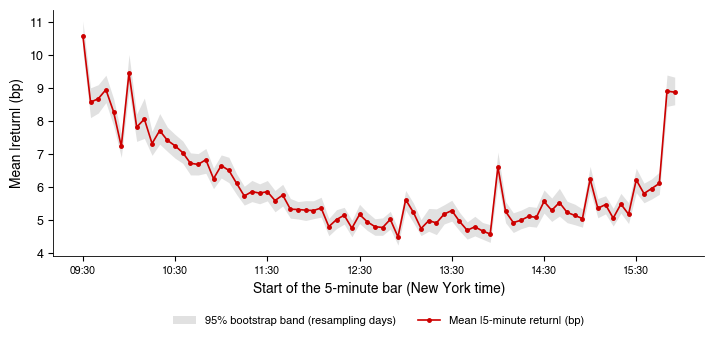

{'ratio': np.float64(2.0611100241206155),
 'lo': 1.9800262772534618,
 'hi': 2.154720227869524,
 'open': np.float64(10.590414985574784),
 'mid': np.float64(5.138209441338895),
 'vshare': np.float64(18.64671431741261),
 'vlo': 18.32366443924597,
 'vhi': 18.985597110968445,
 'n': 1477,
 'absr_close': 8.879817050739323}

In [15]:
# Solution
def b1_ushape():
    s = intraday_spy()
    x = s.dropna(subset=['r'])
    by_day = {}
    for d, g in x.groupby('date'):
        g = g.set_index('tod')
        by_day[d] = (abs(g['r'].get('09:30', np.nan)), g.loc['11:30':'14:00', 'r'].abs().mean(),
                     g['volume'].iloc[-6:].sum() / g['volume'].sum())
    arr = np.array(list(by_day.values()))
    ratio = np.nanmean(arr[:, 0]) / np.nanmean(arr[:, 1])
    lo, hi = boot_days(by_day, lambda v: np.nanmean([a[0] for a in v]) / np.nanmean([a[1] for a in v]))
    vs = np.nanmean(arr[:, 2])
    vlo, vhi = boot_days(by_day, lambda v: np.nanmean([a[2] for a in v]))
    tod = spy_tod(s)
    # grafic: media |r| pe intervale, cu benzi bootstrap pe zile
    piv = x.pivot_table(index='date', columns='tod', values='r', aggfunc=lambda v: abs(v).mean())
    rng = np.random.default_rng(SEED)
    bs = np.array([piv.iloc[rng.integers(0, len(piv), len(piv))].mean().values for _ in range(300)])
    lo_b, hi_b = 1e4 * np.nanpercentile(bs, 2.5, axis=0), 1e4 * np.nanpercentile(bs, 97.5, axis=0)
    k = np.arange(len(piv.columns))
    fig, ax = plt.subplots(figsize=(8.4, 3.2))
    ax.fill_between(k, lo_b, hi_b, color='#DADADA', alpha=0.8, lw=0, label='95% bootstrap band (resampling days)')
    ax.plot(k, 1e4 * piv.mean().values, color=IDAred, lw=1.2, marker='o', ms=2.5, label='Mean |5-minute return| (bp)')
    ax.set_xticks(k[::12])
    ax.set_xticklabels(piv.columns[::12], fontsize=7.5)
    ax.set_xlabel('Start of the 5-minute bar (New York time)')
    ax.set_ylabel('Mean |return| (bp)')
    legend_outside_bottom(ax, ncol=2, y=-0.2)
    save_fig('ch10_sem_ushape')
    return dict(ratio=ratio, lo=lo, hi=hi, open=1e4 * np.nanmean(arr[:, 0]), mid=1e4 * np.nanmean(arr[:, 1]),
                vshare=100 * vs, vlo=100 * vlo, vhi=100 * vhi, n=len(by_day), absr_close=float(tod['absr'].iloc[-1]))


b1_ushape()

### B2. Spread estimators at two frequencies [Solved]

- Roll, Corwin–Schultz, Abdi–Ranaldo for SPY from 5-minute and daily bars, with bootstrap intervals; one price step as a benchmark.
- Interpretation: which frequency gives a credible spread?

In [16]:
# Solution
def b2_spreads():
    s = intraday_spy()
    E = intraday_spreads(s)
    by_day = {d: row for d, row in E.iterrows()}
    roll5 = 1e4 * 2 * np.sqrt(max(-E['cov'].mean(), 0))
    rlo, rhi = boot_days(by_day, lambda v: 1e4 * 2 * np.sqrt(max(-np.mean([r['cov'] for r in v]), 0)))
    cs5 = 1e4 * E['cs'].mean()
    clo, chi = boot_days(by_day, lambda v: 1e4 * np.mean([r['cs'] for r in v]))
    ar5 = 1e4 * np.sqrt(max(E['ar2'].mean(), 0))
    alo, ahi = boot_days(by_day, lambda v: 1e4 * np.sqrt(max(np.mean([r['ar2'] for r in v]), 0)))
    tick = 1e4 * (0.01 / E['price']).mean()
    # date zilnice: bootstrap pe blocuri mobile de 20 de zile
    d = ohlc('SPY', START2)
    cs = cs_spread(d['high'], d['low'])
    ar2 = ar_terms(d['close'], d['high'], d['low'])
    rng = np.random.default_rng(SEED)
    n, L = len(cs), 20
    csb, arb = [], []
    for _ in range(B):
        st = rng.integers(0, n - L, n // L + 1)
        idx = np.concatenate([np.arange(a, a + L) for a in st])[:n]
        csb.append(1e4 * cs[idx].mean())
        arb.append(1e4 * np.sqrt(max(ar2[idx].mean(), 0)))
    sd_daily = 1e4 * np.log(d['close']).diff().std()
    return dict(roll5=roll5, rlo=rlo, rhi=rhi, cs5=cs5, clo=clo, chi=chi, ar5=ar5, alo=alo, ahi=ahi, tick=tick,
                cs_d=1e4 * cs.mean(), cs_dlo=float(np.percentile(csb, 2.5)), cs_dhi=float(np.percentile(csb, 97.5)),
                ar_d=1e4 * np.sqrt(max(ar2.mean(), 0)), ar_dlo=float(np.percentile(arb, 2.5)),
                ar_dhi=float(np.percentile(arb, 97.5)), sd_daily=sd_daily, share_negcov=float((E['cov'] < 0).mean()))


b2_spreads()

{'roll5': np.float64(2.8178694948515814),
 'rlo': 2.088525758122144,
 'rhi': 3.4255275546874655,
 'cs5': np.float64(3.114235796578159),
 'clo': 3.0289837140441147,
 'chi': 3.2013723971846413,
 'ar5': np.float64(1.0597709930490853),
 'alo': 0.0,
 'ahi': 1.667760884627947,
 'tick': np.float64(0.2065684865019977),
 'cs_d': np.float64(22.390237058522164),
 'cs_dlo': 17.42412538028882,
 'cs_dhi': 29.449564938969115,
 'ar_d': np.float64(55.09545779283073),
 'ar_dlo': 0.0,
 'ar_dhi': 92.63874164256617,
 'sd_daily': 103.3794289113439,
 'share_negcov': 0.5924170616113744}

### B3. Spread estimates across 25 assets [Proposed]

- Corwin–Schultz and Abdi–Ranaldo from daily bars; Spearman correlations with volatility and traded value. Model: B2.
- Interpretation: which measure would you trust to compare markets?

In [ ]:
# Your code here


### B4. Illiquidity and the VIX [Solved]

- Regression of log intraday illiquidity of SPY on log VIX; OLS vs HAC standard errors; with a time trend.
- Interpretation: elasticity; why the standard errors differ; is the relation causal?

In [18]:
# Solution
def b4_illiq_vix():
    s = intraday_spy()
    ill = spy_illiq_daily(s)
    vix = read_market('VIX.INDX')['close'].rename('vix')
    j = pd.concat([ill, vix], axis=1, join='inner').dropna()
    y, X = np.log(j['illiq']), sm.add_constant(np.log(j['vix']))
    ols = sm.OLS(y, X).fit()
    hac = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
    # control pentru nivelul valorii tranzactionate (tendinta)
    dvd = s.groupby('date')['dv'].sum().rename('dv')
    j2 = pd.concat([j, dvd], axis=1, join='inner').dropna()
    X2 = sm.add_constant(pd.DataFrame({'lvix': np.log(j2['vix']), 't': np.arange(len(j2)) / 252}))
    hac2 = sm.OLS(np.log(j2['illiq']), X2).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
    rho1 = float(np.corrcoef(ols.resid[1:], ols.resid[:-1])[0, 1])
    return dict(b=float(hac.params.iloc[1]), se_ols=float(ols.bse.iloc[1]), se_hac=float(hac.bse.iloc[1]),
                lo=float(hac.params.iloc[1] - 1.96 * hac.bse.iloc[1]), hi=float(hac.params.iloc[1] + 1.96 * hac.bse.iloc[1]),
                r2=float(ols.rsquared), n=int(len(j)), rho1=rho1, b2=float(hac2.params['lvix']),
                se2=float(hac2.bse['lvix']), trend=float(hac2.params['t']), se_trend=float(hac2.bse['t']))


b4_illiq_vix()

{'b': 0.9544304059527832,
 'se_ols': 0.03762559414053015,
 'se_hac': 0.12116131927996482,
 'lo': 0.7169542201640522,
 'hi': 1.1919065917415141,
 'r2': 0.30373962833787016,
 'n': 1477,
 'rho1': 0.7589592718584635,
 'b2': 0.8042733818184661,
 'se2': 0.12031769162600765,
 'trend': -0.0616845891503183,
 'se_trend': 0.021082133375156693}

### B5. Amihud illiquidity on three markets [Proposed]

- Group medians, BVB / US ratio with a bootstrap interval, year-on-year rank stability. Model: B2, B4.
- Interpretation: how much less liquid is the BVB?

In [ ]:
# Your code here


### B6. Volume and price moves in SPY bars [Proposed]

- Log-log slope of mean |r| on relative volume (20 groups, day bootstrap) and at bar level with day-clustered errors; test 0.5. Model: B4.
- Interpretation: is this the square-root law?

In [ ]:
# Your code here


### B7. The Bitcoin clock [Proposed]

- US morning vs Asian and European morning; weekdays vs weekends; 95% intervals resampling days. Model: B1.
- Interpretation: why does a 24/7 market have a clock?

In [ ]:
# Your code here


## Part C — does illiquidity carry a premium on the BVB? [Proposed]

- Monthly market returns (BET-TR, SPY, Bitcoin) on lagged market illiquidity and its AR(1) shock, HAC standard errors (Amihud, 2002).
- BVB cross-section: illiquid minus liquid stocks, rebalanced every year.

In [ ]:
# Your code here
